In [1]:
import pandas as pd

train = pd.read_csv("train.csv")

train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
train.shape

(1460, 81)

In [3]:
train.columns.tolist()

['Id',
 'MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF'

In [4]:
# Count how many missing (empty/NaN) values are present in each column
train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [5]:
# Show only columns that contain missing values
# This helps us quickly identify which columns need attention later
missing_values = train.isnull().sum()

missing_values[missing_values > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [6]:
# Check whether any complete rows are duplicated
# Duplicate rows can cause problems during model training
train.duplicated().sum()

np.int64(0)

In [7]:
# Show basic statistics of house sale prices
# This helps us understand the minimum, maximum, average, etc.
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

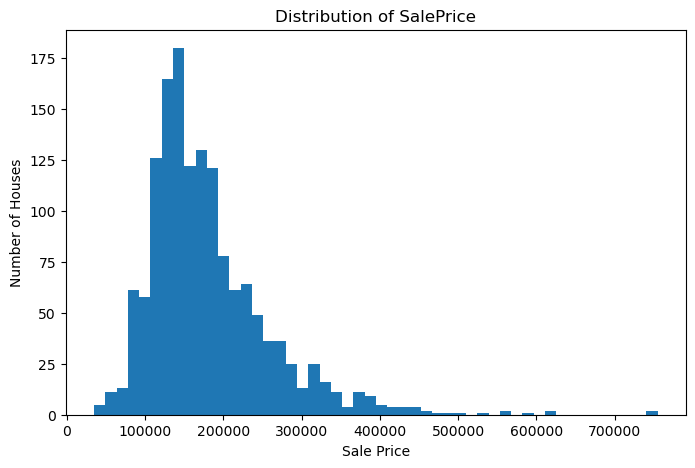

In [8]:
import matplotlib.pyplot as plt

# Plot the distribution of house prices
# This helps us visually see whether SalePrice is skewed
plt.figure(figsize=(8, 5))
plt.hist(train["SalePrice"], bins=50)

plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of SalePrice")

plt.show()

In [9]:
# Find correlations between numerical columns and SalePrice
# Higher correlation means a stronger relationship with house price

correlation = train.select_dtypes(include="number").corr()["SalePrice"]

correlation.sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [10]:
# Show the 10 numerical features least related to SalePrice
# This helps us identify features that may have weak linear relationships
correlation.sort_values().head(10)

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
Name: SalePrice, dtype: float64

In [11]:
# Show column names, data types, and number of non-missing values
# This gives us one overall summary of the dataset
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [12]:
# Check the data type of our target variable
# SalePrice is the value that our model will learn to predict
train["SalePrice"].dtype

dtype('int64')

In [13]:
# Check whether our target variable has any missing values
# We cannot train a supervised model if the target value is missing
train["SalePrice"].isnull().sum()

np.int64(0)

In [14]:
# Check whether every house has a unique ID
# ID is usually just an identifier, not a useful price-predicting feature
train["Id"].nunique()

1460

In [15]:
# Check how much the mean price differs from the median price
# A noticeable difference can indicate skewness
print("Mean:", train["SalePrice"].mean())
print("Median:", train["SalePrice"].median())

Mean: 180921.19589041095
Median: 163000.0


In [16]:
# Count how many houses have each OverallQual value
# OverallQual represents the overall material and finish quality of the house
train["OverallQual"].value_counts().sort_index()


OverallQual
1       2
2       3
3      20
4     116
5     397
6     374
7     319
8     168
9      43
10     18
Name: count, dtype: int64

In [17]:
# Calculate the average SalePrice for each OverallQual score
# This helps us see whether higher-quality houses generally cost more
train.groupby("OverallQual")["SalePrice"].mean()

OverallQual
1      50150.000000
2      51770.333333
3      87473.750000
4     108420.655172
5     133523.347607
6     161603.034759
7     207716.423197
8     274735.535714
9     367513.023256
10    438588.388889
Name: SalePrice, dtype: float64

In [18]:
# Calculate the average SalePrice for different living-area ranges
# This helps us understand the relationship between house size and price

train.groupby(
    pd.qcut(train["GrLivArea"], 5)
)["SalePrice"].mean()

C:\Temp\ipykernel_2252\1102019857.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby(


GrLivArea
(333.999, 1066.6]    115749.503425
(1066.6, 1339.0]     143937.597270
(1339.0, 1578.0]     172873.715753
(1578.0, 1869.0]     204546.763699
(1869.0, 5642.0]     267923.006873
Name: SalePrice, dtype: float64

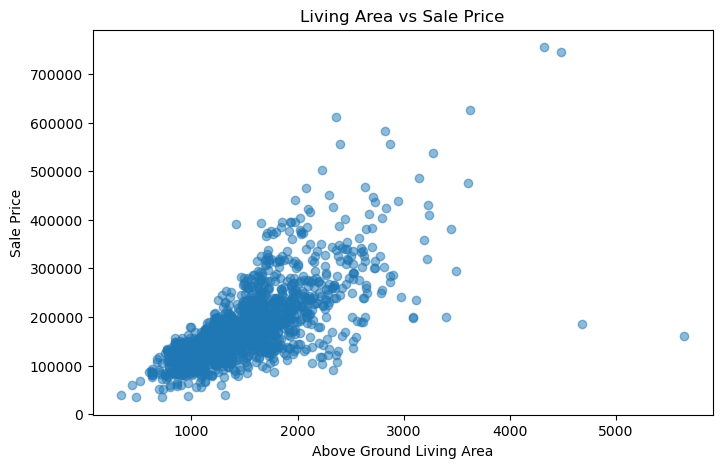

In [19]:
import matplotlib.pyplot as plt

# Show the relationship between living area and house price
# Each dot represents one house
plt.figure(figsize=(8, 5))
plt.scatter(train["GrLivArea"], train["SalePrice"], alpha=0.5)

plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")
plt.title("Living Area vs Sale Price")

plt.show()

In [20]:
# Find houses with very large living areas
# We will inspect these later because unusual values can affect our model

train.nlargest(10, "GrLivArea")[["GrLivArea", "SalePrice"]]

,GrLivArea,SalePrice
1298,5642,160000
523,4676,184750
1182,4476,745000
691,4316,755000
1169,3627,625000
185,3608,475000
304,3493,295000
1268,3447,381000
635,3395,200000
769,3279,538000


In [21]:
# Count houses with GrLivArea greater than 4000 sq ft
# This helps us see how rare these extreme values are
(train["GrLivArea"] > 4000).sum()

np.int64(4)

In [22]:
# Select columns that contain text/categorical values
# These columns will need special preprocessing later
categorical_columns = train.select_dtypes(include="object").columns

print("Number of categorical columns:", len(categorical_columns))
print(categorical_columns.tolist())

Number of categorical columns: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [23]:
# Select columns containing numerical values
# These features can be used directly by our numerical preprocessing
numerical_columns = train.select_dtypes(include="number").columns

print("Number of numerical columns:", len(numerical_columns))
print(numerical_columns.tolist())

Number of numerical columns: 38
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [24]:
# X = input features used by the model
# y = target value that the model needs to predict

X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 80)
y shape: (1460,)


In [25]:
# Display the first 5 rows of our input features
# SalePrice is no longer included in X
X.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


In [26]:
# Display the first 5 house prices
# These are the target values our model will learn to predict
y.head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

In [27]:
# Check how many target values we have
# We should have one SalePrice for every house
y.shape

(1460,)

In [28]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
# 80% → model learns from this
# 20% → we use this later to test the model
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Validation data:", X_valid.shape)

Training data: (1168, 80)
Validation data: (292, 80)


In [29]:
# Check that the training and validation sets have the correct number of rows
# Together they should add back up to the original 1460 houses
print(len(X_train) + len(X_valid))

1460


In [30]:
# Check how many house prices are in each split
# There should be 1168 training prices and 292 validation prices
print("Training prices:", len(y_train))
print("Validation prices:", len(y_valid))

Training prices: 1168
Validation prices: 292


In [31]:
# Check that X and y have the same number of rows
# Every house in X must have exactly one SalePrice in y

print(X_train.shape[0] == y_train.shape[0])
print(X_valid.shape[0] == y_valid.shape[0])

True
True


In [32]:
# Check that training and validation sets do not contain the same rows
# This helps confirm there is no accidental overlap
print("Training rows:", len(X_train))
print("Validation rows:", len(X_valid))
print("Total rows:", len(X_train) + len(X_valid))

Training rows: 1168
Validation rows: 292
Total rows: 1460


In [33]:
# Count missing values in the training data
# We will use this information to decide how to handle missing values later
X_train.isnull().sum().sort_values(ascending=False).head(10)

PoolQC         1162
MiscFeature    1122
Alley          1094
Fence           935
MasVnrType      683
FireplaceQu     547
LotFrontage     217
GarageCond       64
GarageType       64
GarageYrBlt      64
dtype: int64

In [34]:
# Show the different PoolQC categories
# We want to understand what a missing value means here
train["PoolQC"].value_counts(dropna=False)

PoolQC
NaN    1453
Gd        3
Ex        2
Fa        2
Name: count, dtype: int64

In [35]:
# Check the values in Alley, including missing values
# This helps us understand what NaN means for this feature
train["Alley"].value_counts(dropna=False)


Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

In [36]:
# Check the values in MiscFeature, including missing values
# We want to understand what NaN means for this feature
train["MiscFeature"].value_counts(dropna=False)

MiscFeature
NaN     1406
Shed      49
Gar2       2
Othr       2
TenC       1
Name: count, dtype: int64

In [37]:
# Check Fence values, including missing values
# This helps us understand what NaN means for the fence feature
train["Fence"].value_counts(dropna=False)

Fence
NaN      1179
MnPrv     157
GdPrv      59
GdWo       54
MnWw       11
Name: count, dtype: int64

In [38]:
# Check the values in MasVnrType, including missing values
# This tells us what kind of masonry veneer the house has
train["MasVnrType"].value_counts(dropna=False)

MasVnrType
NaN        872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [39]:
# Check fireplace quality values, including missing values
# This helps us understand what NaN means for FireplaceQu
train["FireplaceQu"].value_counts(dropna=False)

FireplaceQu
NaN    690
Gd     380
TA     313
Fa      33
Ex      24
Po      20
Name: count, dtype: int64

In [40]:
# Check garage type values, including missing values
# This helps us understand whether NaN means no garage
train["GarageType"].value_counts(dropna=False)

GarageType
Attchd     870
Detchd     387
BuiltIn     88
NaN         81
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

In [41]:
# Check missing values in the year the garage was built
# We want to understand what NaN means for GarageYrBlt
train["GarageYrBlt"].isnull().sum()

np.int64(81)

In [42]:
# Check garage finish values, including missing values
# This tells us whether NaN means the house has no garage
train["GarageFinish"].value_counts(dropna=False)

GarageFinish
Unf    605
RFn    422
Fin    352
NaN     81
Name: count, dtype: int64

In [43]:
# Check garage quality values, including missing values
# This helps us confirm that NaN means there is no garage
train["GarageQual"].value_counts(dropna=False)


GarageQual
TA     1311
NaN      81
Fa       48
Gd       14
Ex        3
Po        3
Name: count, dtype: int64

In [44]:
# Check garage condition values, including missing values
# This tells us whether NaN also means there is no garage
train["GarageCond"].value_counts(dropna=False)

GarageCond
TA     1326
NaN      81
Fa       35
Gd        9
Po        7
Ex        2
Name: count, dtype: int64

In [45]:
# Check garage condition values, including missing values
# This tells us whether NaN also means there is no garage
train["GarageCond"].value_counts(dropna=False)


GarageCond
TA     1326
NaN      81
Fa       35
Gd        9
Po        7
Ex        2
Name: count, dtype: int64

In [46]:
# Check the Electrical categories, including the missing value
# We want to understand how this missing value should be handled
train["Electrical"].value_counts(dropna=False)

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
NaN         1
Name: count, dtype: int64

In [47]:
# Show all columns that still contain missing values
# We will handle these systematically in the preprocessing stage
missing = X_train.isnull().sum()
missing[missing > 0].sort_values(ascending=False)


PoolQC          1162
MiscFeature     1122
Alley           1094
Fence            935
MasVnrType       683
FireplaceQu      547
LotFrontage      217
GarageType        64
GarageYrBlt       64
GarageFinish      64
GarageQual        64
GarageCond        64
BsmtFinType1      28
BsmtFinType2      28
BsmtExposure      28
BsmtCond          28
BsmtQual          28
MasVnrArea         6
Electrical         1
dtype: int64

In [48]:
# Identify numerical input features
# SalePrice is already removed from X, so everything here is an input feature
numerical_features = X_train.select_dtypes(include="number").columns

# Identify categorical/text input features
categorical_features = X_train.select_dtypes(include="object").columns

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 37
Categorical features: 43


In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical columns:
# Replace missing numbers with the median
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical columns:
# Replace missing categories with the most frequent category
# Then convert text categories into numbers using One-Hot Encoding
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [50]:
# Learn preprocessing rules only from the training data
# This is important because it prevents data leakage from validation data
preprocessor.fit(X_train)

print("Preprocessing fitted successfully!")

Preprocessing fitted successfully!


In [51]:
# Apply the preprocessing rules to the training data
# This converts categorical text into numbers and fills missing values
X_train_processed = preprocessor.transform(X_train)

print("Processed training shape:", X_train_processed.shape)

Processed training shape: (1168, 286)


In [52]:
# Apply the already-fitted preprocessing to validation data
# We use transform(), NOT fit_transform(), to prevent data leakage
X_valid_processed = preprocessor.transform(X_valid)

print("Processed validation shape:", X_valid_processed.shape)

Processed validation shape: (292, 286)


In [53]:
# Apply the same preprocessing rules to validation data
# We do NOT fit again on validation data
X_valid_processed = preprocessor.transform(X_valid)

print("Processed validation shape:", X_valid_processed.shape)

Processed validation shape: (292, 286)


In [54]:
# Check whether preprocessing successfully removed all missing values
import numpy as np

print("Missing values in training:", np.isnan(X_train_processed.toarray()).sum())

Missing values in training: 0


In [55]:
# Check that validation data also has no missing values
print("Missing values in validation:", np.isnan(X_valid_processed.toarray()).sum())

Missing values in validation: 0


In [56]:
# Show the first 5 training house prices
# These are the target values our model will learn to predict
y_train.head()

254     145000
1066    178000
638      85000
799     175000
380     127000
Name: SalePrice, dtype: int64

In [57]:
# Check what format our processed training data has
# This tells us how the machine-learning model will receive the features
print(type(X_train_processed))


<class 'scipy.sparse._csr.csr_matrix'>


In [58]:
from sklearn.ensemble import RandomForestRegressor

# Create our first machine-learning model
# Random Forest combines many decision trees to make a prediction
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

print("Random Forest created successfully!")

Random Forest created successfully!


In [59]:
# Train the Random Forest using our training data
# The model learns the relationship between house features and SalePrice
rf_model.fit(X_train_processed, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [60]:
# Predict house prices for the validation data
# The model has never seen these 292 houses during training
rf_pred = rf_model.predict(X_valid_processed)

print("Predictions created:", len(rf_pred))

Predictions created: 292


In [61]:
from sklearn.metrics import mean_absolute_error

# Compare predicted prices with actual prices
# Lower MAE means better predictions
rf_mae = mean_absolute_error(y_valid, rf_pred)

print("Random Forest MAE:", rf_mae)

Random Forest MAE: 17494.2626369863


In [62]:
from sklearn.metrics import mean_squared_error
import numpy as np

# RMSE penalizes large prediction errors more heavily than MAE
# Lower RMSE is better
rf_rmse = np.sqrt(mean_squared_error(y_valid, rf_pred))

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 28480.77943628507


In [63]:
from sklearn.metrics import r2_score

# R² measures how well the model explains differences in house prices
# Higher R² is better; 1.0 means a perfect model
rf_r2 = r2_score(y_valid, rf_pred)

print("Random Forest R²:", rf_r2)

Random Forest R²: 0.8942476792527724


In [64]:
# Store our first Random Forest results for easy comparison later
rf_results = {
    "Model": "Random Forest",
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "R2": rf_r2
}

rf_results

{'Model': 'Random Forest',
 'MAE': 17494.2626369863,
 'RMSE': np.float64(28480.77943628507),
 'R2': 0.8942476792527724}

In [65]:
# Install XGBoost in the same Python environment used by this notebook
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [66]:
from xgboost import XGBRegressor

# Create an XGBoost regression model
# XGBoost builds trees sequentially, each one trying to correct previous errors
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    random_state=42,
    n_jobs=-1
)

print("XGBoost created successfully!")

XGBoost created successfully!


In [67]:
# Train XGBoost on the training data
# The model learns the relationship between house features and SalePrice
xgb_model.fit(X_train_processed, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [68]:
# Predict house prices for the validation data
# These houses were not used while training XGBoost
xgb_pred = xgb_model.predict(X_valid_processed)

print("XGBoost predictions created:", len(xgb_pred))

XGBoost predictions created: 292


In [69]:
from sklearn.metrics import mean_absolute_error

# Calculate the average absolute prediction error
# Lower MAE means better predictions
xgb_mae = mean_absolute_error(y_valid, xgb_pred)

print("XGBoost MAE:", xgb_mae)

XGBoost MAE: 15667.517578125


In [70]:
from sklearn.metrics import mean_squared_error
import numpy as np

# RMSE gives more penalty to large prediction errors
# Lower RMSE is better
xgb_rmse = np.sqrt(mean_squared_error(y_valid, xgb_pred))

print("XGBoost RMSE:", xgb_rmse)

XGBoost RMSE: 25406.45839151927


In [71]:
from sklearn.metrics import r2_score

# R² tells us how much of the price variation the model explains
# Higher R² is better
xgb_r2 = r2_score(y_valid, xgb_pred)

print("XGBoost R²:", xgb_r2)

XGBoost R²: 0.915846049785614


In [72]:
# Store XGBoost results so we can compare all models later
xgb_results = {
    "Model": "XGBoost",
    "MAE": xgb_mae,
    "RMSE": xgb_rmse,
    "R2": xgb_r2
}

xgb_results

{'Model': 'XGBoost',
 'MAE': 15667.517578125,
 'RMSE': np.float64(25406.45839151927),
 'R2': 0.915846049785614}

In [73]:
# Install LightGBM in the same environment used by this notebook
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [74]:
from lightgbm import LGBMRegressor

# Create a LightGBM regression model
# LightGBM is another gradient-boosting model
lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

print("LightGBM created successfully!")

LightGBM created successfully!


In [75]:
# Train LightGBM on our training data
# The model learns the relationship between house features and SalePrice
lgb_model.fit(X_train_processed, y_train)

print("LightGBM trained successfully!")

LightGBM trained successfully!


In [76]:
# Predict house prices for the validation data
# These 292 houses were not used during LightGBM training
lgb_pred = lgb_model.predict(X_valid_processed)

print("LightGBM predictions created:", len(lgb_pred))

LightGBM predictions created: 292


In [77]:
from sklearn.metrics import mean_absolute_error

# Calculate the average prediction error of LightGBM
# Lower MAE means better predictions
lgb_mae = mean_absolute_error(y_valid, lgb_pred)

print("LightGBM MAE:", lgb_mae)

LightGBM MAE: 16615.07088281969


In [78]:
from sklearn.metrics import mean_squared_error
import numpy as np

# RMSE gives more penalty to large prediction errors
# Lower RMSE is better
lgb_rmse = np.sqrt(mean_squared_error(y_valid, lgb_pred))

print("LightGBM RMSE:", lgb_rmse)

LightGBM RMSE: 29285.87885628916


In [79]:
from sklearn.metrics import r2_score

# Calculate how much variation in house prices LightGBM explains
# Higher R² is better
lgb_r2 = r2_score(y_valid, lgb_pred)

print("LightGBM R²:", lgb_r2)

LightGBM R²: 0.888184325253128


In [80]:
# Store LightGBM results so we can compare all three models later
lgb_results = {
    "Model": "LightGBM",
    "MAE": lgb_mae,
    "RMSE": lgb_rmse,
    "R2": lgb_r2
}

lgb_results

{'Model': 'LightGBM',
 'MAE': 16615.07088281969,
 'RMSE': np.float64(29285.87885628916),
 'R2': 0.888184325253128}

In [81]:
# Combine the results of all three models into one table
# This makes it easy to compare their performance
results = pd.DataFrame([
    rf_results,
    xgb_results,
    lgb_results
])

results

,Model,MAE,RMSE,R2
0,Random Forest,17494.262637,28480.779436,0.894248
1,XGBoost,15667.517578,25406.458392,0.915846
2,LightGBM,16615.070883,29285.878856,0.888184


In [82]:
from sklearn.model_selection import KFold

# Divide the 1168 training houses into 5 folds
# Each house will be used for validation once
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold cross-validation created!")

5-fold cross-validation created!


In [83]:
# Show how the 1168 training houses are divided into 5 folds
# The output will show which rows are used for training and validation in each fold

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), start=1):
    print(f"Fold {fold}:")
    print("  Training houses:", len(train_idx))
    print("  Validation houses:", len(val_idx))

Fold 1:
  Training houses: 934
  Validation houses: 234
Fold 2:
  Training houses: 934
  Validation houses: 234
Fold 3:
  Training houses: 934
  Validation houses: 234
Fold 4:
  Training houses: 935
  Validation houses: 233
Fold 5:
  Training houses: 935
  Validation houses: 233


In [84]:
import numpy as np

# Create empty arrays to store Out-of-Fold (OOF) predictions
# One prediction will be stored for every training house
oof_rf = np.zeros(len(X_train))
oof_xgb = np.zeros(len(X_train))
oof_lgb = np.zeros(len(X_train))

print("OOF prediction arrays created!")

OOF prediction arrays created!


In [85]:
from sklearn.ensemble import RandomForestRegressor

# Create a fresh Random Forest model for the first fold
# This model will train only on the fold's training data
rf_fold_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

print("Fold Random Forest created!")

Fold Random Forest created!


In [86]:
# Get the row numbers for Fold 1
# These indices tell us which houses to train on and which houses to predict
train_idx, val_idx = next(kf.split(X_train))

print("Training houses:", len(train_idx))
print("Validation houses:", len(val_idx))

Training houses: 934
Validation houses: 234


In [87]:
# Get the actual data for Fold 1
# 934 houses will be used to train the model
# 234 houses will be used to create OOF predictions

X_fold_train = X_train_processed[train_idx]
X_fold_val = X_train_processed[val_idx]

y_fold_train = y_train.iloc[train_idx]
y_fold_val = y_train.iloc[val_idx]

print("Fold training shape:", X_fold_train.shape)
print("Fold validation shape:", X_fold_val.shape)

Fold training shape: (934, 286)
Fold validation shape: (234, 286)


In [88]:
# Train Random Forest only on Fold 1 training data
# It will NOT see the 234 validation houses
rf_fold_model.fit(X_fold_train, y_fold_train)

print("Fold 1 Random Forest trained successfully!")

Fold 1 Random Forest trained successfully!


In [89]:
# Predict the 234 houses that Random Forest did NOT train on
# These predictions become honest OOF predictions for Fold 1
rf_fold_pred = rf_fold_model.predict(X_fold_val)

print("Fold 1 predictions:", len(rf_fold_pred))

Fold 1 predictions: 234


In [90]:
# Store Fold 1 predictions in the OOF array
# val_idx tells us exactly where these 234 predictions belong
oof_rf[val_idx] = rf_fold_pred

print("Fold 1 OOF predictions stored!")

Fold 1 OOF predictions stored!


In [91]:
# Count how many OOF predictions have been filled so far
# Fold 1 should have filled 234 predictions
print("OOF predictions stored:", np.count_nonzero(oof_rf))

OOF predictions stored: 234


In [92]:
# Run only Fold 2, 3, 4, and 5
# Fold 1 is already completed and stored in oof_rf

folds = list(kf.split(X_train))

for fold, (train_idx, val_idx) in enumerate(folds[1:], start=2):

    print(f"\n========== Fold {fold} ==========")

    # Get this fold's training and validation data
    X_fold_train = X_train_processed[train_idx]
    X_fold_val = X_train_processed[val_idx]
    y_fold_train = y_train.iloc[train_idx]

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_fold_train, y_fold_train)
    oof_rf[val_idx] = rf.predict(X_fold_val)

    # XGBoost
    xgb = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(X_fold_train, y_fold_train)
    oof_xgb[val_idx] = xgb.predict(X_fold_val)

    # LightGBM
    lgb = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    lgb.fit(X_fold_train, y_fold_train)
    oof_lgb[val_idx] = lgb.predict(X_fold_val)

    print(f"Fold {fold} completed")

print("\nRemaining folds completed!")


========== Fold 2 ==========
Fold 2 completed

========== Fold 3 ==========
Fold 3 completed

========== Fold 4 ==========
Fold 4 completed

========== Fold 5 ==========
Fold 5 completed

Remaining folds completed!


In [93]:
# Check that all 1168 training houses received an OOF prediction
print("RF OOF:", np.count_nonzero(oof_rf))
print("XGB OOF:", np.count_nonzero(oof_xgb))
print("LGB OOF:", np.count_nonzero(oof_lgb))

RF OOF: 1168
XGB OOF: 934
LGB OOF: 934


In [94]:
# Get Fold 1 indices again
folds = list(kf.split(X_train))
train_idx_1, val_idx_1 = folds[0]

# Prepare Fold 1 data
X_fold_train = X_train_processed[train_idx_1]
X_fold_val = X_train_processed[val_idx_1]
y_fold_train = y_train.iloc[train_idx_1]

# -----------------------------
# XGBoost - Fold 1
# -----------------------------
xgb_fold1 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    random_state=42,
    n_jobs=-1
)

xgb_fold1.fit(X_fold_train, y_fold_train)

# Store predictions for Fold 1
oof_xgb[val_idx_1] = xgb_fold1.predict(X_fold_val)

print("Fold 1 XGBoost completed")


# -----------------------------
# LightGBM - Fold 1
# -----------------------------
lgb_fold1 = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_fold1.fit(X_fold_train, y_fold_train)

# Store predictions for Fold 1
oof_lgb[val_idx_1] = lgb_fold1.predict(X_fold_val)

print("Fold 1 LightGBM completed")

Fold 1 XGBoost completed
Fold 1 LightGBM completed


In [95]:
# Check that every one of the 1168 training houses has an OOF prediction
print("RF OOF:", np.count_nonzero(oof_rf))
print("XGB OOF:", np.count_nonzero(oof_xgb))
print("LGB OOF:", np.count_nonzero(oof_lgb))

RF OOF: 1168
XGB OOF: 1168
LGB OOF: 1168


In [96]:
# Create the dataset that the meta-model will learn from
# Each column contains predictions from one base model
stacking_data = pd.DataFrame({
    "RF_Pred": oof_rf,
    "XGB_Pred": oof_xgb,
    "LGB_Pred": oof_lgb
})

# Add the actual house prices
stacking_data["ActualPrice"] = y_train.values

print("Stacking dataset shape:", stacking_data.shape)
stacking_data.head()

Stacking dataset shape: (1168, 4)


,RF_Pred,XGB_Pred,LGB_Pred,ActualPrice
0,147034.250,148261.796875,148117.790799,145000
1,173973.325,178595.890625,175234.277957,178000
2,100636.165,101443.312500,98435.809745,85000
3,154292.790,146757.015625,151324.086723,175000
4,138421.590,142778.843750,142660.595927,127000


In [97]:
from sklearn.linear_model import Ridge

# Create the meta-model
# It will learn how to combine predictions from RF, XGBoost, and LightGBM
meta_model = Ridge(alpha=1.0)

print("Meta-model created successfully!")

Meta-model created successfully!


In [98]:
# Select the three base-model predictions as inputs
meta_X = stacking_data[["RF_Pred", "XGB_Pred", "LGB_Pred"]]

# The actual house prices are the target
meta_y = stacking_data["ActualPrice"]

# Train the meta-model
meta_model.fit(meta_X, meta_y)

print("Meta-model trained successfully!")

Meta-model trained successfully!


In [99]:
# Get predictions from the three base models on the untouched validation data
# These 292 houses were never used to train the base models

rf_valid_pred = rf_model.predict(X_valid_processed)
xgb_valid_pred = xgb_model.predict(X_valid_processed)
lgb_valid_pred = lgb_model.predict(X_valid_processed)

print("RF predictions:", len(rf_valid_pred))
print("XGB predictions:", len(xgb_valid_pred))
print("LGB predictions:", len(lgb_valid_pred))

RF predictions: 292
XGB predictions: 292
LGB predictions: 292


In [100]:
# Combine the three base-model predictions
# These become the inputs for our trained meta-model
meta_valid_X = pd.DataFrame({
    "RF_Pred": rf_valid_pred,
    "XGB_Pred": xgb_valid_pred,
    "LGB_Pred": lgb_valid_pred
})

print("Meta validation shape:", meta_valid_X.shape)
meta_valid_X.head()

Meta validation shape: (292, 3)


,RF_Pred,XGB_Pred,LGB_Pred
0,140783.625,140844.421875,141925.817028
1,326644.285,345028.875000,334304.729784
2,116734.910,113957.601562,117085.127471
3,153235.920,155123.000000,160515.118364
4,328990.675,333393.937500,337418.492442


In [101]:
# Use the three base-model predictions to make the final stacking prediction
# The Ridge meta-model combines all three predictions
stacking_pred = meta_model.predict(meta_valid_X)

print("Stacking predictions:", len(stacking_pred))

Stacking predictions: 292


In [102]:
from sklearn.metrics import mean_absolute_error

# Compare the final stacking predictions with the actual validation prices
# Lower MAE means better average prediction accuracy
stacking_mae = mean_absolute_error(y_valid, stacking_pred)

print("Stacking MAE:", stacking_mae)

Stacking MAE: 16115.3790748711


In [103]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate RMSE for the stacking model
# Lower RMSE is better
stacking_rmse = np.sqrt(mean_squared_error(y_valid, stacking_pred))

print("Stacking RMSE:", stacking_rmse)

Stacking RMSE: 27474.795642157616


In [104]:
from sklearn.metrics import r2_score

# Calculate how much variation in house prices the stacking model explains
# Higher R² is better
stacking_r2 = r2_score(y_valid, stacking_pred)

print("Stacking R²:", stacking_r2)

Stacking R²: 0.9015864025612089


In [105]:
# ============================================================
# STAGE 106: ADVANCED FEATURE ENGINEERING + PREPROCESSING
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


# ------------------------------------------------------------
# 1. Copy the original dataset
# ------------------------------------------------------------
# We create a new copy so our original 'train' dataframe stays untouched.

df = train.copy()


# ------------------------------------------------------------
# 2. Create advanced engineered features
# ------------------------------------------------------------

# Total square footage:
# Basement + 1st floor + 2nd floor
df["TotalSF"] = (
    df["TotalBsmtSF"] +
    df["1stFlrSF"] +
    df["2ndFlrSF"]
)

# Total finished basement area
df["TotalBsmtFin"] = (
    df["BsmtFinSF1"] +
    df["BsmtFinSF2"]
)

# Total bathroom score:
# Full bathroom = 1
# Half bathroom = 0.5
# Basement full bathroom = 1
# Basement half bathroom = 0.5
df["TotalBathrooms"] = (
    df["FullBath"]
    + 0.5 * df["HalfBath"]
    + df["BsmtFullBath"]
    + 0.5 * df["BsmtHalfBath"]
)

# Total porch/deck area
df["TotalPorchSF"] = (
    df["OpenPorchSF"]
    + df["EnclosedPorch"]
    + df["3SsnPorch"]
    + df["ScreenPorch"]
    + df["WoodDeckSF"]
)

# Age of the house when it was sold
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

# Age of the house since the last remodeling
df["RemodelAge"] = df["YrSold"] - df["YearRemodAdd"]

# Age of the garage when the house was sold
df["GarageAge"] = df["YrSold"] - df["GarageYrBlt"]

# Total above-ground + basement living area
df["TotalLivingArea"] = df["GrLivArea"] + df["TotalBsmtSF"]

# Interaction between quality and above-ground living area
# This captures the idea that a large, high-quality house can have
# a different price effect than a large, low-quality house.
df["OverallQual_GrLivArea"] = (
    df["OverallQual"] * df["GrLivArea"]
)

# Interaction between quality and total square footage
df["OverallQual_TotalSF"] = (
    df["OverallQual"] * df["TotalSF"]
)

# Garage-related indicators
# 1 = garage exists, 0 = no garage
df["HasGarage"] = (df["GarageArea"] > 0).astype(int)

# Basement indicator
df["HasBsmt"] = (df["TotalBsmtSF"] > 0).astype(int)

# Fireplace indicator
df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)

# Pool indicator
df["HasPool"] = (df["PoolArea"] > 0).astype(int)

# Second-floor indicator
df["Has2ndFloor"] = (df["2ndFlrSF"] > 0).astype(int)


# ------------------------------------------------------------
# 3. Separate input features (X) and target (y)
# ------------------------------------------------------------

# SalePrice is our target and must NOT be used as an input feature.
X_fe = df.drop("SalePrice", axis=1)
y_fe = df["SalePrice"]


# ------------------------------------------------------------
# 4. Create a fresh 80/20 train-validation split
# ------------------------------------------------------------

# 80% -> training
# 20% -> validation
# random_state=42 keeps the split reproducible.
X_fe_train, X_fe_valid, y_fe_train, y_fe_valid = train_test_split(
    X_fe,
    y_fe,
    test_size=0.20,
    random_state=42
)


# ------------------------------------------------------------
# 5. Identify numerical and categorical features
# ------------------------------------------------------------

numerical_features_fe = X_fe_train.select_dtypes(
    include="number"
).columns

categorical_features_fe = X_fe_train.select_dtypes(
    include="object"
).columns


# ------------------------------------------------------------
# 6. Identify categorical columns where NaN means
#    "the house does not have this feature"
# ------------------------------------------------------------

# For these columns, "None" is more meaningful than
# replacing the missing value with the most frequent category.
none_category_columns = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]


# ------------------------------------------------------------
# 7. Create numerical preprocessing pipeline
# ------------------------------------------------------------

# Numerical missing values are filled with the median.
numeric_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])


# ------------------------------------------------------------
# 8. Create categorical preprocessing pipeline
# ------------------------------------------------------------

# First fill missing categories with "None".
# Then handle any remaining missing categorical values
# using the most frequent category.
# Finally convert categorical values into numerical columns.
categorical_pipeline_fe = Pipeline([
    ("imputer_none", SimpleImputer(
        strategy="constant",
        fill_value="None"
    )),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])


# ------------------------------------------------------------
# 9. Create the complete preprocessing transformer
# ------------------------------------------------------------

preprocessor_fe = ColumnTransformer([
    ("num", numeric_pipeline_fe, numerical_features_fe),
    ("cat", categorical_pipeline_fe, categorical_features_fe)
])


# ------------------------------------------------------------
# 10. Fit ONLY on training data
# ------------------------------------------------------------

# This is important for preventing data leakage.
preprocessor_fe.fit(X_fe_train)


# ------------------------------------------------------------
# 11. Transform training and validation data
# ------------------------------------------------------------

X_fe_train_processed = preprocessor_fe.transform(X_fe_train)

X_fe_valid_processed = preprocessor_fe.transform(X_fe_valid)


# ------------------------------------------------------------
# 12. Print verification information
# ------------------------------------------------------------

print("===== FEATURE ENGINEERING COMPLETED =====")
print("Original features:", X.shape[1])
print("New features:", X_fe.shape[1])
print("Engineered features created:", X_fe.shape[1] - X.shape[1])

print("\nTraining data:", X_fe_train.shape)
print("Validation data:", X_fe_valid.shape)

print("\nProcessed training:", X_fe_train_processed.shape)
print("Processed validation:", X_fe_valid_processed.shape)

print("\nNumerical features:", len(numerical_features_fe))
print("Categorical features:", len(categorical_features_fe))

print("\nFeature engineering + preprocessing completed successfully!")

===== FEATURE ENGINEERING COMPLETED =====
Original features: 80
New features: 95
Engineered features created: 15

Training data: (1168, 95)
Validation data: (292, 95)

Processed training: (1168, 317)
Processed validation: (292, 317)

Numerical features: 52
Categorical features: 43

Feature engineering + preprocessing completed successfully!


In [106]:
# ============================================================
# STAGE 107: RETRAIN MODELS WITH ADVANCED FEATURES
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Create Random Forest
# ------------------------------------------------------------
# Same model settings as our earlier baseline,
# so we can fairly compare the effect of feature engineering.
rf_fe = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# 2. Create XGBoost
# ------------------------------------------------------------
xgb_fe = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# 3. Create LightGBM
# ------------------------------------------------------------
lgb_fe = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)


# ------------------------------------------------------------
# 4. Train all three models
# ------------------------------------------------------------

print("Training Random Forest...")
rf_fe.fit(X_fe_train_processed, y_fe_train)

print("Training XGBoost...")
xgb_fe.fit(X_fe_train_processed, y_fe_train)

print("Training LightGBM...")
lgb_fe.fit(X_fe_train_processed, y_fe_train)

print("\nAll three models trained successfully!")


# ------------------------------------------------------------
# 5. Make validation predictions
# ------------------------------------------------------------

rf_fe_pred = rf_fe.predict(X_fe_valid_processed)
xgb_fe_pred = xgb_fe.predict(X_fe_valid_processed)
lgb_fe_pred = lgb_fe.predict(X_fe_valid_processed)


# ------------------------------------------------------------
# 6. Create a function to calculate all metrics
# ------------------------------------------------------------

def evaluate_model(model_name, y_true, y_pred):
    """
    Calculate MAE, RMSE and R² for a model.
    """

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


# ------------------------------------------------------------
# 7. Evaluate all three models
# ------------------------------------------------------------

feature_engineering_results = pd.DataFrame([
    evaluate_model(
        "Random Forest + FE",
        y_fe_valid,
        rf_fe_pred
    ),

    evaluate_model(
        "XGBoost + FE",
        y_fe_valid,
        xgb_fe_pred
    ),

    evaluate_model(
        "LightGBM + FE",
        y_fe_valid,
        lgb_fe_pred
    )
])


# ------------------------------------------------------------
# 8. Display final comparison
# ------------------------------------------------------------

print("\n===== FEATURE ENGINEERING MODEL RESULTS =====")

feature_engineering_results

Training Random Forest...
Training XGBoost...
Training LightGBM...

All three models trained successfully!

===== FEATURE ENGINEERING MODEL RESULTS =====


,Model,MAE,RMSE,R2
0,Random Forest + FE,17325.818031,29250.581112,0.888454
1,XGBoost + FE,16007.388672,26203.198583,0.910485
2,LightGBM + FE,16961.432260,29287.205859,0.888174


In [107]:
# ============================================================
# STAGE 108: TARGET TRANSFORMATION EXPERIMENT
# ============================================================

import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ------------------------------------------------------------
# 1. Transform the training target
# ------------------------------------------------------------
# log1p(x) = log(1 + x)
# This reduces the strong right-skew in house prices.
y_fe_train_log = np.log1p(y_fe_train)


# ------------------------------------------------------------
# 2. Create a fresh XGBoost model
# ------------------------------------------------------------
xgb_log = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# 3. Train XGBoost on log-transformed prices
# ------------------------------------------------------------
print("Training XGBoost with log-transformed target...")

xgb_log.fit(
    X_fe_train_processed,
    y_fe_train_log
)


# ------------------------------------------------------------
# 4. Predict validation prices
# ------------------------------------------------------------
# The prediction is currently in log scale.
log_predictions = xgb_log.predict(
    X_fe_valid_processed
)


# ------------------------------------------------------------
# 5. Convert predictions back to original dollar scale
# ------------------------------------------------------------
# expm1() is the inverse of log1p().
xgb_log_pred = np.expm1(log_predictions)


# ------------------------------------------------------------
# 6. Evaluate on the ORIGINAL price scale
# ------------------------------------------------------------
log_mae = mean_absolute_error(
    y_fe_valid,
    xgb_log_pred
)

log_rmse = np.sqrt(
    mean_squared_error(
        y_fe_valid,
        xgb_log_pred
    )
)

log_r2 = r2_score(
    y_fe_valid,
    xgb_log_pred
)


# ------------------------------------------------------------
# 7. Display results
# ------------------------------------------------------------
print("\n===== XGBOOST WITH LOG TARGET =====")
print("MAE :", log_mae)
print("RMSE:", log_rmse)
print("R2  :", log_r2)

print("\n===== CURRENT BEST BASELINE =====")
print("XGBoost + FE")
print("MAE :", feature_engineering_results.loc[
    feature_engineering_results["Model"] == "XGBoost + FE", "MAE"
].iloc[0])
print("RMSE:", feature_engineering_results.loc[
    feature_engineering_results["Model"] == "XGBoost + FE", "RMSE"
].iloc[0])
print("R2  :", feature_engineering_results.loc[
    feature_engineering_results["Model"] == "XGBoost + FE", "R2"
].iloc[0])

Training XGBoost with log-transformed target...

===== XGBOOST WITH LOG TARGET =====
MAE : 16014.8291015625
RMSE: 26539.780255307316
R2  : 0.9081708192825317

===== CURRENT BEST BASELINE =====
XGBoost + FE
MAE : 16007.388671875
RMSE: 26203.19858337909
R2  : 0.9104852080345154


In [108]:
# ============================================================
# STAGE 109: XGBOOST HYPERPARAMETER TUNING
# ============================================================

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Create the XGBoost model
# ------------------------------------------------------------
# We give RandomizedSearchCV a flexible XGBoost model.
# The best hyperparameters will be found automatically.

xgb_tuning = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# 2. Define the hyperparameters we want to test
# ------------------------------------------------------------
# Each parameter controls a different part of XGBoost.

param_distributions = {
    # Number of trees
    "n_estimators": [300, 500, 700, 900],

    # How strongly each tree learns from previous errors
    "learning_rate": [0.02, 0.03, 0.05, 0.08],

    # Maximum depth of each tree
    "max_depth": [3, 4, 5, 6],

    # Minimum amount of data needed to create a child
    "min_child_weight": [1, 3, 5, 7],

    # Percentage of training rows used by each tree
    "subsample": [0.7, 0.8, 0.9, 1.0],

    # Percentage of features used by each tree
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],

    # L1 regularization
    "reg_alpha": [0, 0.01, 0.1, 1],

    # L2 regularization
    "reg_lambda": [1, 2, 5, 10]
}


# ------------------------------------------------------------
# 3. RandomizedSearchCV
# ------------------------------------------------------------
# Instead of testing every possible combination,
# RandomizedSearchCV tests a selected number of combinations.
#
# 5-fold CV means:
# The 1168 training houses are divided into 5 folds.
# Each combination is evaluated using those 5 folds.
#
# IMPORTANT:
# The untouched 292 validation houses are NOT used here.

random_search = RandomizedSearchCV(
    estimator=xgb_tuning,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


# ------------------------------------------------------------
# 4. Run hyperparameter search
# ------------------------------------------------------------

print("Starting XGBoost hyperparameter tuning...")
print("12 parameter combinations × 5-fold CV")

random_search.fit(
    X_train_processed,
    y_train
)

print("\nHyperparameter tuning completed!")


# ------------------------------------------------------------
# 5. Show the best hyperparameters
# ------------------------------------------------------------

print("\n===== BEST HYPERPARAMETERS =====")

best_params = random_search.best_params_

for parameter, value in best_params.items():
    print(f"{parameter}: {value}")


# ------------------------------------------------------------
# 6. Show the best cross-validation RMSE
# ------------------------------------------------------------
# RandomizedSearchCV stores negative RMSE because sklearn
# assumes that higher scores are better.
#
# We multiply by -1 to get the normal RMSE.

best_cv_rmse = -random_search.best_score_

print("\nBest CV RMSE:", best_cv_rmse)


# ------------------------------------------------------------
# 7. Get the best tuned XGBoost model
# ------------------------------------------------------------

best_xgb = random_search.best_estimator_


# ------------------------------------------------------------
# 8. Test the tuned model on our untouched 292 houses
# ------------------------------------------------------------

tuned_pred = best_xgb.predict(X_valid_processed)


# ------------------------------------------------------------
# 9. Calculate final validation metrics
# ------------------------------------------------------------

tuned_mae = mean_absolute_error(
    y_valid,
    tuned_pred
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        tuned_pred
    )
)

tuned_r2 = r2_score(
    y_valid,
    tuned_pred
)


# ------------------------------------------------------------
# 10. Display final validation results
# ------------------------------------------------------------

print("\n===== TUNED XGBOOST VALIDATION RESULTS =====")

print("MAE :", tuned_mae)
print("RMSE:", tuned_rmse)
print("R2  :", tuned_r2)


# ------------------------------------------------------------
# 11. Compare against our previous best XGBoost
# ------------------------------------------------------------

print("\n===== PREVIOUS BEST XGBOOST =====")

print("MAE : 15667.52")
print("RMSE: 25406.46")
print("R2  : 0.91585")


# ------------------------------------------------------------
# 12. Simple improvement check
# ------------------------------------------------------------

if tuned_r2 > 0.91585:
    print("\nResult: Tuned XGBoost improved our previous R2!")
else:
    print("\nResult: Tuned XGBoost did not beat our previous R2.")

Starting XGBoost hyperparameter tuning...
12 parameter combinations × 5-fold CV
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Hyperparameter tuning completed!

===== BEST HYPERPARAMETERS =====
subsample: 0.9
reg_lambda: 1
reg_alpha: 0.01
n_estimators: 900
min_child_weight: 3
max_depth: 3
learning_rate: 0.02
colsample_bytree: 0.8

Best CV RMSE: 28016.716796875

===== TUNED XGBOOST VALIDATION RESULTS =====
MAE : 15718.0546875
RMSE: 24869.62227296587
R2  : 0.9193648099899292

===== PREVIOUS BEST XGBOOST =====
MAE : 15667.52
RMSE: 25406.46
R2  : 0.91585

Result: Tuned XGBoost improved our previous R2!


In [109]:
# ============================================================
# STAGE 110: TUNE RANDOM FOREST + LIGHTGBM
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd


# ============================================================
# 1. RANDOM FOREST TUNING
# ============================================================

rf_tuning = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [None, 10, 15, 20, 25],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.8, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=rf_params,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting Random Forest tuning...")

rf_search.fit(
    X_train_processed,
    y_train
)

best_rf = rf_search.best_estimator_

rf_best_cv_rmse = -rf_search.best_score_

print("\n===== BEST RANDOM FOREST PARAMETERS =====")

for parameter, value in rf_search.best_params_.items():
    print(f"{parameter}: {value}")

print("Best RF CV RMSE:", rf_best_cv_rmse)


# Test tuned Random Forest on untouched validation data
rf_tuned_pred = best_rf.predict(X_valid_processed)

rf_tuned_mae = mean_absolute_error(
    y_valid,
    rf_tuned_pred
)

rf_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        rf_tuned_pred
    )
)

rf_tuned_r2 = r2_score(
    y_valid,
    rf_tuned_pred
)


# ============================================================
# 2. LIGHTGBM TUNING
# ============================================================

lgb_tuning = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_params = {
    "n_estimators": [300, 500, 700, 900],
    "learning_rate": [0.02, 0.03, 0.05, 0.08],
    "max_depth": [-1, 3, 5, 7],
    "num_leaves": [15, 31, 50, 70],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0, 1, 5, 10]
}

lgb_search = RandomizedSearchCV(
    estimator=lgb_tuning,
    param_distributions=lgb_params,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nStarting LightGBM tuning...")

lgb_search.fit(
    X_train_processed,
    y_train
)

best_lgb = lgb_search.best_estimator_

lgb_best_cv_rmse = -lgb_search.best_score_

print("\n===== BEST LIGHTGBM PARAMETERS =====")

for parameter, value in lgb_search.best_params_.items():
    print(f"{parameter}: {value}")

print("Best LGBM CV RMSE:", lgb_best_cv_rmse)


# Test tuned LightGBM on untouched validation data
lgb_tuned_pred = best_lgb.predict(X_valid_processed)

lgb_tuned_mae = mean_absolute_error(
    y_valid,
    lgb_tuned_pred
)

lgb_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        lgb_tuned_pred
    )
)

lgb_tuned_r2 = r2_score(
    y_valid,
    lgb_tuned_pred
)


# ============================================================
# 3. FINAL TUNED MODEL COMPARISON
# ============================================================

tuned_model_results = pd.DataFrame([
    {
        "Model": "Tuned Random Forest",
        "MAE": rf_tuned_mae,
        "RMSE": rf_tuned_rmse,
        "R2": rf_tuned_r2
    },
    {
        "Model": "Tuned XGBoost",
        "MAE": tuned_mae,
        "RMSE": tuned_rmse,
        "R2": tuned_r2
    },
    {
        "Model": "Tuned LightGBM",
        "MAE": lgb_tuned_mae,
        "RMSE": lgb_tuned_rmse,
        "R2": lgb_tuned_r2
    }
])

print("\n===== TUNED MODEL COMPARISON =====")

tuned_model_results

Starting Random Forest tuning...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

===== BEST RANDOM FOREST PARAMETERS =====
n_estimators: 600
min_samples_split: 2
min_samples_leaf: 1
max_features: sqrt
max_depth: 15
Best RF CV RMSE: 30753.006995271106

Starting LightGBM tuning...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

===== BEST LIGHTGBM PARAMETERS =====
subsample: 0.9
reg_lambda: 1
reg_alpha: 0.1
num_leaves: 31
n_estimators: 700
min_child_samples: 20
max_depth: 3
learning_rate: 0.08
colsample_bytree: 0.7
Best LGBM CV RMSE: 27257.54803797427

===== TUNED MODEL COMPARISON =====


,Model,MAE,RMSE,R2
0,Tuned Random Forest,18224.333884,32565.029775,0.861742
1,Tuned XGBoost,15718.054688,24869.622273,0.919365
2,Tuned LightGBM,17073.180297,28264.725483,0.895846


In [110]:
# ============================================================
# STAGE 111: FINAL STACKING WITH TUNED MODELS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ------------------------------------------------------------
# 1. Create 5-fold cross-validation
# ------------------------------------------------------------
# We use only the 1168 training houses here.
# The 292 final validation houses remain untouched.

kf_final = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# 2. Create empty OOF prediction arrays
# ------------------------------------------------------------
# Each training house will receive exactly one prediction
# from each tuned base model.

oof_rf_final = np.zeros(len(X_train))
oof_xgb_final = np.zeros(len(X_train))
oof_lgb_final = np.zeros(len(X_train))


# ------------------------------------------------------------
# 3. Generate OOF predictions
# ------------------------------------------------------------
# clone() creates a fresh copy of each tuned model.
# This prevents the model from reusing knowledge from the
# earlier full-training stage.

for fold, (train_idx, val_idx) in enumerate(
    kf_final.split(X_train),
    start=1
):

    print(f"\n========== Fold {fold} ==========")

    # Get fold-specific data
    X_fold_train = X_train_processed[train_idx]
    X_fold_val = X_train_processed[val_idx]

    y_fold_train = y_train.iloc[train_idx]

    print("Training houses:", len(train_idx))
    print("Validation houses:", len(val_idx))


    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------
    rf_fold = clone(best_rf)

    rf_fold.fit(
        X_fold_train,
        y_fold_train
    )

    oof_rf_final[val_idx] = rf_fold.predict(
        X_fold_val
    )

    print("Random Forest OOF complete")


    # --------------------------------------------------------
    # XGBoost
    # --------------------------------------------------------
    xgb_fold = clone(best_xgb)

    xgb_fold.fit(
        X_fold_train,
        y_fold_train
    )

    oof_xgb_final[val_idx] = xgb_fold.predict(
        X_fold_val
    )

    print("XGBoost OOF complete")


    # --------------------------------------------------------
    # LightGBM
    # --------------------------------------------------------
    lgb_fold = clone(best_lgb)

    lgb_fold.fit(
        X_fold_train,
        y_fold_train
    )

    oof_lgb_final[val_idx] = lgb_fold.predict(
        X_fold_val
    )

    print("LightGBM OOF complete")


# ------------------------------------------------------------
# 4. Verify OOF predictions
# ------------------------------------------------------------

print("\n===== OOF VERIFICATION =====")

print(
    "RF OOF:",
    np.count_nonzero(oof_rf_final),
    "/",
    len(X_train)
)

print(
    "XGB OOF:",
    np.count_nonzero(oof_xgb_final),
    "/",
    len(X_train)
)

print(
    "LGB OOF:",
    np.count_nonzero(oof_lgb_final),
    "/",
    len(X_train)
)


# ------------------------------------------------------------
# 5. Create the meta-model training dataset
# ------------------------------------------------------------
# These are honest predictions because every prediction was
# generated by a model that did not train on that house.

meta_train = pd.DataFrame({
    "RF_Pred": oof_rf_final,
    "XGB_Pred": oof_xgb_final,
    "LGB_Pred": oof_lgb_final
})


# ------------------------------------------------------------
# 6. Create the Ridge meta-model
# ------------------------------------------------------------
# Ridge learns how to combine the three model predictions.

final_meta_model = Ridge(
    alpha=1.0
)


# ------------------------------------------------------------
# 7. Train the meta-model
# ------------------------------------------------------------

final_meta_model.fit(
    meta_train,
    y_train
)

print("\nFinal Ridge meta-model trained successfully!")


# ------------------------------------------------------------
# 8. Get predictions from the tuned base models
#    on the untouched 292 validation houses
# ------------------------------------------------------------

final_rf_valid = best_rf.predict(
    X_valid_processed
)

final_xgb_valid = best_xgb.predict(
    X_valid_processed
)

final_lgb_valid = best_lgb.predict(
    X_valid_processed
)


# ------------------------------------------------------------
# 9. Create meta-model input for validation houses
# ------------------------------------------------------------

meta_valid = pd.DataFrame({
    "RF_Pred": final_rf_valid,
    "XGB_Pred": final_xgb_valid,
    "LGB_Pred": final_lgb_valid
})


# ------------------------------------------------------------
# 10. Make the FINAL STACKING prediction
# ------------------------------------------------------------

final_stacking_pred = final_meta_model.predict(
    meta_valid
)


# ------------------------------------------------------------
# 11. Evaluation function
# ------------------------------------------------------------

def calculate_metrics(model_name, y_true, predictions):

    mae = mean_absolute_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    r2 = r2_score(
        y_true,
        predictions
    )

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


# ------------------------------------------------------------
# 12. Compare tuned base models vs final stacking
# ------------------------------------------------------------

final_results = pd.DataFrame([

    calculate_metrics(
        "Tuned Random Forest",
        y_valid,
        final_rf_valid
    ),

    calculate_metrics(
        "Tuned XGBoost",
        y_valid,
        final_xgb_valid
    ),

    calculate_metrics(
        "Tuned LightGBM",
        y_valid,
        final_lgb_valid
    ),

    calculate_metrics(
        "Final Stacking",
        y_valid,
        final_stacking_pred
    )
])


# ------------------------------------------------------------
# 13. Display final comparison
# ------------------------------------------------------------

print("\n==========================================")
print("FINAL STACKING MODEL COMPARISON")
print("==========================================")

final_results


========== Fold 1 ==========
Training houses: 934
Validation houses: 234
Random Forest OOF complete
XGBoost OOF complete
LightGBM OOF complete

========== Fold 2 ==========
Training houses: 934
Validation houses: 234
Random Forest OOF complete
XGBoost OOF complete
LightGBM OOF complete

========== Fold 3 ==========
Training houses: 934
Validation houses: 234
Random Forest OOF complete
XGBoost OOF complete
LightGBM OOF complete

========== Fold 4 ==========
Training houses: 935
Validation houses: 233
Random Forest OOF complete
XGBoost OOF complete
LightGBM OOF complete

========== Fold 5 ==========
Training houses: 935
Validation houses: 233
Random Forest OOF complete
XGBoost OOF complete
LightGBM OOF complete

===== OOF VERIFICATION =====
RF OOF: 1168 / 1168
XGB OOF: 1168 / 1168
LGB OOF: 1168 / 1168

Final Ridge meta-model trained successfully!

FINAL STACKING MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Tuned Random Forest,18224.333884,32565.029775,0.861742
1,Tuned XGBoost,15718.054688,24869.622273,0.919365
2,Tuned LightGBM,17073.180297,28264.725483,0.895846
3,Final Stacking,15871.831874,26317.668282,0.909701


In [112]:
# Install SHAP in the same environment used by this notebook
%pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


SHAP values calculated successfully!

Creating SHAP summary plot...


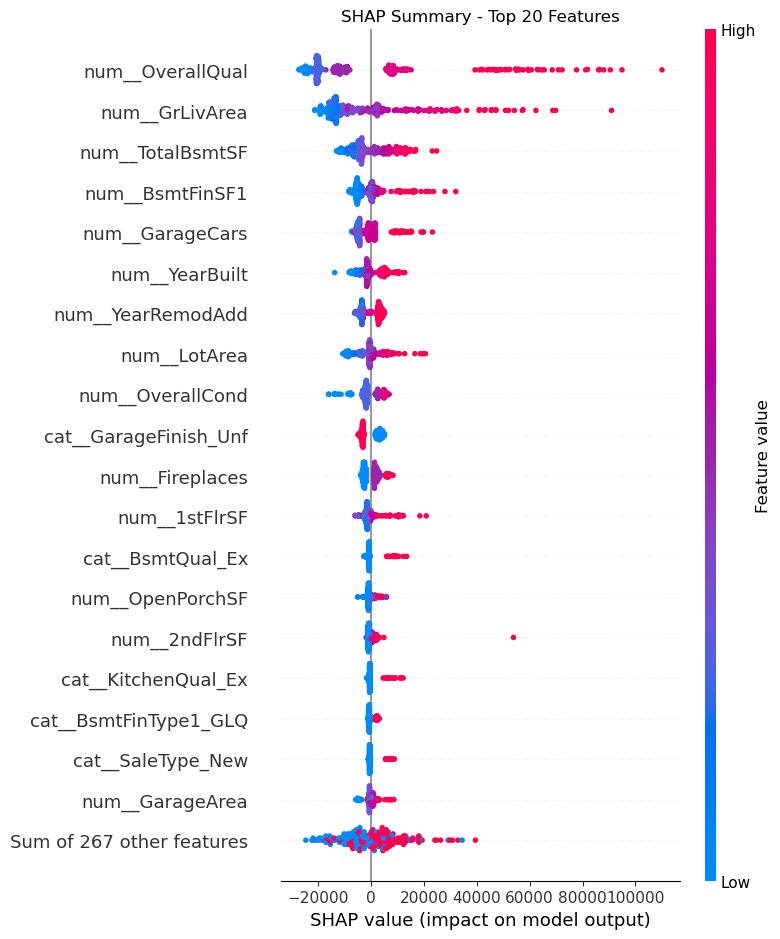


Creating SHAP feature importance plot...


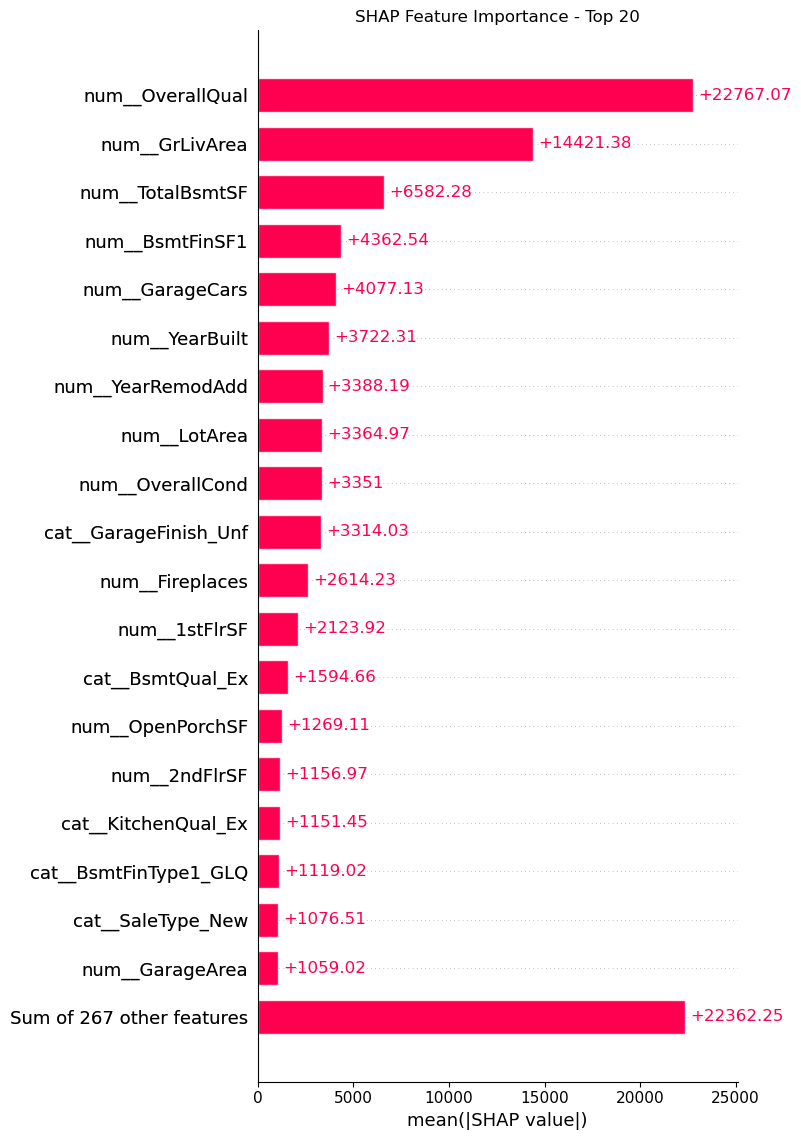


===== INDIVIDUAL HOUSE EXPLANATION =====
Actual price: 154500
Predicted price: 147568.78


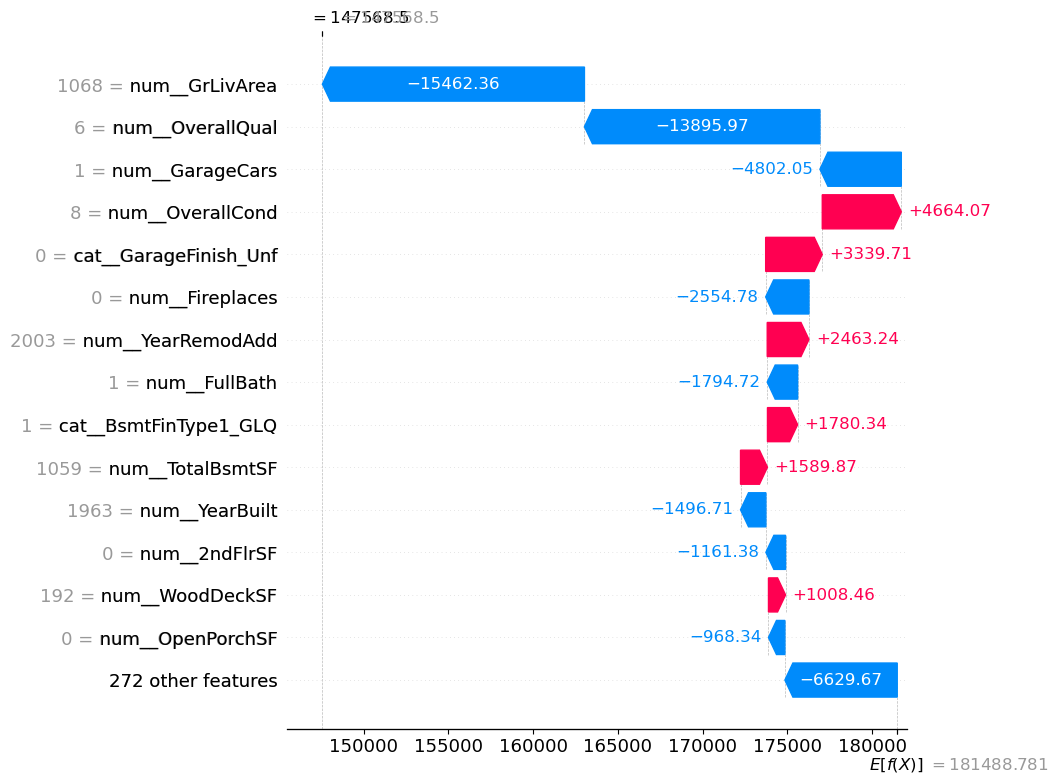

In [113]:
# ============================================================
# STAGE 112: SHAP EXPLAINABILITY
# ============================================================

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. Create SHAP explainer for our final XGBoost model
# ------------------------------------------------------------
# SHAP explains how each feature contributes to predictions.

explainer = shap.TreeExplainer(best_xgb)


# ------------------------------------------------------------
# 2. Calculate SHAP values
# ------------------------------------------------------------
# We use validation data so that explanations are based on
# houses the model did not use during its final training.

shap_values = explainer(
    X_valid_processed
)

print("SHAP values calculated successfully!")


# ------------------------------------------------------------
# 3. Get feature names after preprocessing
# ------------------------------------------------------------
# One-hot encoding created many new feature names.
# We retrieve those names so SHAP plots are understandable.

feature_names = preprocessor.get_feature_names_out()


# ------------------------------------------------------------
# 4. Create a SHAP Explanation object with feature names
# ------------------------------------------------------------

shap_values.feature_names = feature_names


# ------------------------------------------------------------
# 5. Global SHAP summary plot
# ------------------------------------------------------------
# This shows which features are most important overall.

print("\nCreating SHAP summary plot...")

shap.plots.beeswarm(
    shap_values,
    max_display=20,
    show=False
)

plt.title("SHAP Summary - Top 20 Features")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Global feature importance bar plot
# ------------------------------------------------------------
# This shows the average magnitude of each feature's impact.

print("\nCreating SHAP feature importance plot...")

shap.plots.bar(
    shap_values,
    max_display=20,
    show=False
)

plt.title("SHAP Feature Importance - Top 20")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Explain one individual house
# ------------------------------------------------------------
# We explain the first validation house.

house_index = 0

print("\n===== INDIVIDUAL HOUSE EXPLANATION =====")

print(
    "Actual price:",
    y_valid.iloc[house_index]
)

print(
    "Predicted price:",
    tuned_pred[house_index]
)


# ------------------------------------------------------------
# 8. Create waterfall explanation
# ------------------------------------------------------------
# This shows which features pushed the prediction higher
# or lower for this particular house.

shap.plots.waterfall(
    shap_values[house_index],
    max_display=15
)

In [114]:
# ============================================================
# STAGE 113: SAVE FINAL MODEL + PREPROCESSING PIPELINE
# ============================================================

import os
import joblib
import pandas as pd


# ------------------------------------------------------------
# 1. Create a models folder
# ------------------------------------------------------------
# This folder will contain the files needed by our Streamlit app.

os.makedirs("models", exist_ok=True)


# ------------------------------------------------------------
# 2. Create one complete production pipeline
# ------------------------------------------------------------
# IMPORTANT:
# Our final model uses:
#   1. The original preprocessing pipeline
#   2. The tuned XGBoost model
#
# The preprocessing must happen before XGBoost sees the data.

from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_xgb)
])


# ------------------------------------------------------------
# 3. Save the complete pipeline
# ------------------------------------------------------------
# This is the most important file.
# Streamlit will load this file and use it for predictions.

joblib.dump(
    final_pipeline,
    "models/final_house_price_model.joblib"
)


# ------------------------------------------------------------
# 4. Save the final model separately
# ------------------------------------------------------------
# Keeping a separate copy is useful for SHAP and analysis.

joblib.dump(
    best_xgb,
    "models/final_xgboost_model.joblib"
)


# ------------------------------------------------------------
# 5. Save the preprocessing object separately
# ------------------------------------------------------------
# This allows us to inspect or reuse the preprocessing later.

joblib.dump(
    preprocessor,
    "models/preprocessor.joblib"
)


# ------------------------------------------------------------
# 6. Save the final model performance
# ------------------------------------------------------------
# These values document the validation performance of our
# selected production model.

final_metrics = {
    "model": "Tuned XGBoost",
    "MAE": float(tuned_mae),
    "RMSE": float(tuned_rmse),
    "R2": float(tuned_r2)
}

joblib.dump(
    final_metrics,
    "models/final_metrics.joblib"
)


# ------------------------------------------------------------
# 7. Verify that all files were created
# ------------------------------------------------------------

print("===== FILES SAVED =====")

for filename in [
    "final_house_price_model.joblib",
    "final_xgboost_model.joblib",
    "preprocessor.joblib",
    "final_metrics.joblib"
]:
    path = os.path.join("models", filename)

    print(
        filename,
        "→",
        "Created" if os.path.exists(path) else "NOT FOUND"
    )


# ------------------------------------------------------------
# 8. Reload the complete production pipeline
# ------------------------------------------------------------
# This is an important test:
# We don't just save the pipeline — we confirm that it can
# actually be loaded again.

loaded_pipeline = joblib.load(
    "models/final_house_price_model.joblib"
)


# ------------------------------------------------------------
# 9. Test the reloaded pipeline
# ------------------------------------------------------------
# Use one validation house as a test.
# We use the ORIGINAL X_valid row because the saved pipeline
# performs preprocessing internally.

test_house = X_valid.iloc[[0]]

test_prediction = loaded_pipeline.predict(
    test_house
)


# ------------------------------------------------------------
# 10. Display prediction and actual value
# ------------------------------------------------------------

print("\n===== RELOAD TEST =====")

print(
    "Predicted price:",
    round(float(test_prediction[0]), 2)
)

print(
    "Actual price:",
    float(y_valid.iloc[0])
)

print("\nFinal production pipeline saved and verified successfully!")

===== FILES SAVED =====
final_house_price_model.joblib → Created
final_xgboost_model.joblib → Created
preprocessor.joblib → Created
final_metrics.joblib → Created

===== RELOAD TEST =====
Predicted price: 147568.78
Actual price: 154500.0

Final production pipeline saved and verified successfully!


In [116]:
# ============================================================
# TEST ONE HOUSE WITH OUR FINAL TUNED XGBOOST MODEL
# ============================================================

import numpy as np

# Choose a house from the untouched validation set
house_index = 0

# Get that house's original features
house = X_valid.iloc[[house_index]]

# Get the real sale price
actual_price = y_valid.iloc[house_index]

# Predict the price using our final saved pipeline
predicted_price = loaded_pipeline.predict(house)[0]

# Calculate absolute error
absolute_error = abs(actual_price - predicted_price)

# Calculate percentage error
error_percent = (absolute_error / actual_price) * 100

# Calculate how close the prediction was
closeness_percent = 100 - error_percent

print("========== HOUSE PRICE TEST ==========")

print("Actual Price    :", round(actual_price, 2))
print("Predicted Price :", round(predicted_price, 2))
print("Absolute Error  :", round(absolute_error, 2))
print("Error %         :", round(error_percent, 2), "%")
print("Prediction Closeness:", round(closeness_percent, 2), "%")


========== HOUSE PRICE TEST ==========
Actual Price    : 154500
Predicted Price : 147568.78
Absolute Error  : 6931.22
Error %         : 4.49 %
Prediction Closeness: 95.51 %


In [117]:
# ============================================================
# TEST ANOTHER HOUSE
# ============================================================

import random

# Pick another house from the 292 validation houses
house_index = 100

# Get the house features
house = X_valid.iloc[[house_index]]

# Get the real price
actual_price = y_valid.iloc[house_index]

# Predict using our final tuned XGBoost pipeline
predicted_price = loaded_pipeline.predict(house)[0]

# Calculate error
absolute_error = abs(actual_price - predicted_price)
error_percent = (absolute_error / actual_price) * 100
closeness_percent = 100 - error_percent

print("========== HOUSE PRICE TEST ==========")
print("Validation House Index :", house_index)
print("Actual Price           :", round(actual_price, 2))
print("Predicted Price        :", round(predicted_price, 2))
print("Absolute Error         :", round(absolute_error, 2))
print("Error %                :", round(error_percent, 2), "%")
print("Prediction Closeness   :", round(closeness_percent, 2), "%")

========== HOUSE PRICE TEST ==========
Validation House Index : 100
Actual Price           : 163500
Predicted Price        : 174139.45
Absolute Error         : 10639.47
Error %                : 6.51 %
Prediction Closeness   : 93.49 %


In [118]:
# ============================================================
# PREDICT A COMPLETELY UNSEEN HOUSE FROM test.csv
# ============================================================

# Load Kaggle test data
test = pd.read_csv("test.csv")

# Select one house from the test dataset
house_index = 100

# Get the house information
test_house = test.iloc[[house_index]]

# Make prediction using our final saved pipeline
# The pipeline automatically performs preprocessing + XGBoost prediction
predicted_price = loaded_pipeline.predict(test_house)[0]

print("========== UNSEEN KAGGLE TEST HOUSE ==========")
print("Test House Index :", house_index)
print("House ID         :", test_house["Id"].iloc[0])
print("Predicted Price  :", round(predicted_price, 2))

print("\nThis house was NOT used in our training or validation data.")
print("Actual SalePrice is not available in Kaggle test.csv.")

========== UNSEEN KAGGLE TEST HOUSE ==========
Test House Index : 100
House ID         : 1561
Predicted Price  : 132920.0

This house was NOT used in our training or validation data.
Actual SalePrice is not available in Kaggle test.csv.


In [119]:
# ============================================================
# OVERALL MODEL PERFORMANCE ON ALL 292 VALIDATION HOUSES
# ============================================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict all 292 validation houses
all_predictions = loaded_pipeline.predict(X_valid)

# Calculate overall metrics
mae = mean_absolute_error(y_valid, all_predictions)

rmse = np.sqrt(
    mean_squared_error(y_valid, all_predictions)
)

r2 = r2_score(
    y_valid,
    all_predictions
)

# Calculate average percentage error
percentage_errors = (
    np.abs(y_valid.values - all_predictions)
    / y_valid.values
) * 100

mean_percentage_error = percentage_errors.mean()

# A simple "closeness" number
average_closeness = 100 - mean_percentage_error

print("========== OVERALL MODEL PERFORMANCE ==========")
print("Validation houses :", len(y_valid))
print("MAE                :", round(mae, 2))
print("RMSE               :", round(rmse, 2))
print("R²                 :", round(r2, 4))
print("Mean Error %       :", round(mean_percentage_error, 2), "%")
print("Average Closeness  :", round(average_closeness, 2), "%")

========== OVERALL MODEL PERFORMANCE ==========
Validation houses : 292
MAE                : 15718.05
RMSE               : 24869.62
R²                 : 0.9194
Mean Error %       : 9.18 %
Average Closeness  : 90.82 %
